In [1]:
from src.DataFolder import DataFolder
from src.NeuralSignal import NeuralSignal
from src.runtime_logger import logger_setup

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from neurodsp.spectral import compute_spectrum

data_path = "/home/miranjo/phasic_tonic/data/processed/RGS14"
config_path = "/home/miranjo/phasic_tonic/configs/rgs14.yaml"

## Setup

### Load the config file

In [2]:
with open(config_path, 'r') as f:
    args = yaml.safe_load(f)

fs                  = args.pop("fs")
f_theta             = (args.pop("f_theta_lower"), args.pop("f_theta_upper"))
f_lowpass           = args.pop("f_lowpass")
lowpass_length      = args.pop("lowpass_length")
bandpass_length     = args.pop("bandpass_length")
threshold_bycycle   = args.pop("threshold_bycycle")
threshold_episode   = args.pop("threshold_episode")

# Start logger
logger = logger_setup()

### Load the dataset

In [3]:
remFolder = DataFolder(data_path)

# Analysis

## Sample

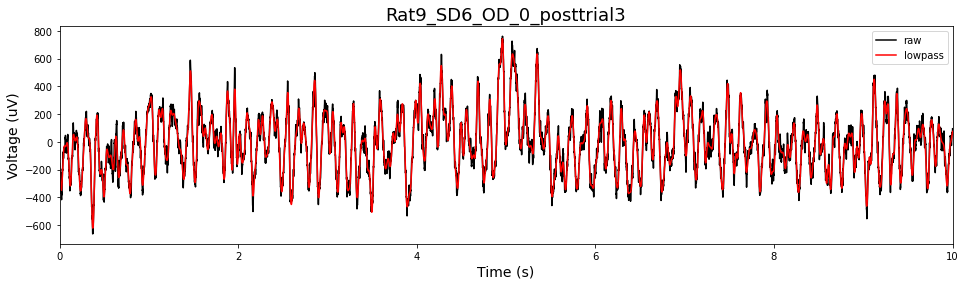

In [4]:
remData = remFolder[0]
arrays = remData["data"]
metadata = remData["metadata"]

theta = NeuralSignal(arrays[0], fs)
theta.set_metadata(metadata)
theta.filter("lowpass", f_range=f_lowpass, n_seconds=lowpass_length)
theta.plot()

In [16]:
metadata

{'RatID': 'Rat2',
 'StudyDay': 'SD2',
 'condition': 'OR',
 'treatment': 'TreatmentNegative',
 'posttrial_number': 'posttrial5'}

## Dataset

In [18]:
spectrum_phasic = []
spectrum_tonic = []

cnt = 0

for sample in remFolder:
    lfpREMs = sample["data"]
    
    for lfpREM in lfpREMs:
        
        if(len(lfpREM) < fs): 
            break    #Skip when the duration is less than a second
        cnt += 1
        theta = NeuralSignal(lfpREM, fs)
        theta.filter('lowpass', f_range=f_lowpass, n_seconds=lowpass_length)
        theta.segment(f_range=f_theta, threshold_episode=threshold_episode, threshold_bycycle=threshold_bycycle)
        
        # Combine all tonic episodes for each REM period
        theta_tonic = np.concatenate(theta.get_tonic(filter_type="raw"))
        logger.debug("tonic shape: {0}".format(theta_tonic.shape))
        
        f, spectrum_t = compute_spectrum(theta_tonic, theta.fs, method='welch', avg_type='mean')
        spectrum_tonic.append(spectrum_t[:100])

        if theta.phasic:
            # Combine all phasic episodes for each REM period
            theta_phasic = np.concatenate(theta.get_phasic(filter_type="raw"))
            logger.debug("phasic shape: {0}".format(theta_phasic.shape))
            
            f, spectrum_p = compute_spectrum(theta_phasic, theta.fs, method='welch', avg_type='mean')
            spectrum_phasic.append(spectrum_p[:100])
            

spectrum_phasic = np.vstack(spectrum_phasic)
spectrum_tonic = np.vstack(spectrum_tonic)

phasic_spectrum_mean = np.mean(spectrum_phasic, axis=0)
tonic_spectrum_mean = np.mean(spectrum_tonic, axis=0)

phasic_spectrum_std = np.std(spectrum_phasic, axis=0)
tonic_spectrum_std = np.std(spectrum_tonic, axis=0)


/home/miranjo/.local/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:2017: UserWarning: nperseg = 1000 is greater than input length  = 982, using nperseg = 982
  warnings.warn('nperseg = {0:d} is greater than input length '
/home/miranjo/.local/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:2017: UserWarning: nperseg = 1000 is greater than input length  = 855, using nperseg = 855
  warnings.warn('nperseg = {0:d} is greater than input length '
/home/miranjo/.local/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:2017: UserWarning: nperseg = 1000 is greater than input length  = 909, using nperseg = 909
  warnings.warn('nperseg = {0:d} is greater than input length '
/home/miranjo/.local/lib/python3.10/site-packages/scipy/signal/_spectral_py.py:2017: UserWarning: nperseg = 1000 is greater than input length  = 977, using nperseg = 977
  warnings.warn('nperseg = {0:d} is greater than input length '
/home/miranjo/.local/lib/python3.10/site-packages/scipy/signal/_

In [20]:
cnt

776

In [21]:
phasic_spectrum_err = phasic_spectrum_std/(len(spectrum_phasic)**0.5)
tonic_spectrum_err = tonic_spectrum_std/(len(spectrum_tonic)**0.5)

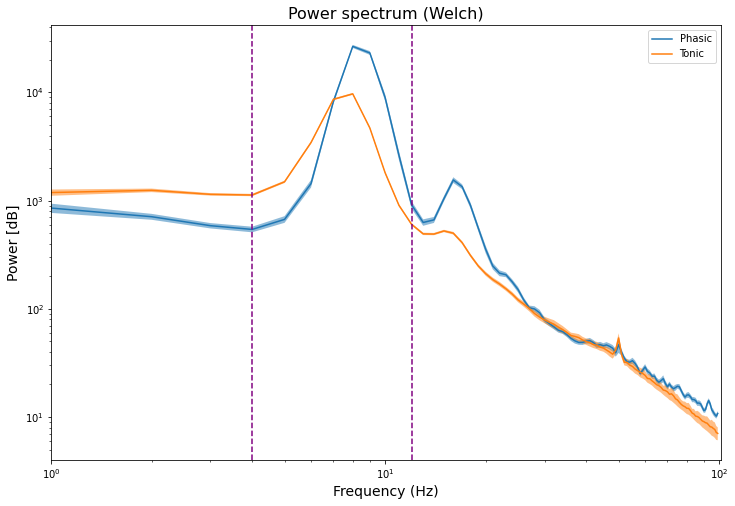

In [22]:
plt.figure(figsize=(12,8))
plt.plot(phasic_spectrum_mean)
plt.plot(tonic_spectrum_mean)

plt.fill_between(np.arange(100), phasic_spectrum_mean - phasic_spectrum_err,
                 phasic_spectrum_mean + phasic_spectrum_err, 
                 alpha=0.5, label='Standard Error of Phasic Spectrum')

plt.fill_between(np.arange(100), tonic_spectrum_mean - tonic_spectrum_err,
                 tonic_spectrum_mean + tonic_spectrum_err, 
                 alpha=0.5, label='Standard Error of Tonic Spectrum')

plt.xlabel('Frequency (Hz)', fontsize=14)
plt.ylabel('Power [dB]', fontsize=14)

plt.yscale('log')
plt.xscale('log')

plt.xlim((1, 101))

plt.axvline(x=4, color='purple', linestyle='--')
plt.axvline(x=12, color='purple', linestyle='--')

plt.title('Power spectrum (Welch)', fontsize=16)
plt.legend(['Phasic', 'Tonic'])

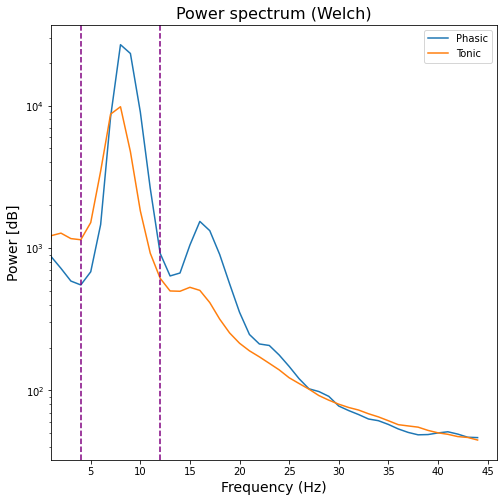

In [9]:
plt.figure(figsize=(8,8))
plt.plot(phasic_spectrum_mean[:45])
plt.plot(tonic_spectrum_mean[:45])

#plt.fill_between(freq, phasic_spectrum_mean - phasic_spectrum_std,
#                 phasic_spectrum_mean + phasic_spectrum_std, 
#                 alpha=0.5, label='Standard Deviation of Phasic Spectrum')
#
#plt.fill_between(freq, tonic_spectrum_mean - tonic_spectrum_std,
#                 tonic_spectrum_mean + tonic_spectrum_std, 
#                 alpha=0.5, label='Standard Deviation of Tonic Spectrum')

plt.xlabel('Frequency (Hz)', fontsize=14)
plt.ylabel('Power [dB]', fontsize=14)

plt.yscale('log')

plt.xlim((1, 46))

plt.axvline(x=4, color='purple', linestyle='--')
plt.axvline(x=12, color='purple', linestyle='--')

plt.title('Power spectrum (Welch)', fontsize=16)
plt.legend(['Phasic', 'Tonic'])

{'whiskers': [<matplotlib.lines.Line2D at 0x7fa2a6794520>,
 'caps': [<matplotlib.lines.Line2D at 0x7fa2a6794ac0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7fa2a6794340>,
 'medians': [<matplotlib.lines.Line2D at 0x7fa2a6795060>,
 'fliers': [<matplotlib.lines.Line2D at 0x7fa2a6795330>,
 'means': []}

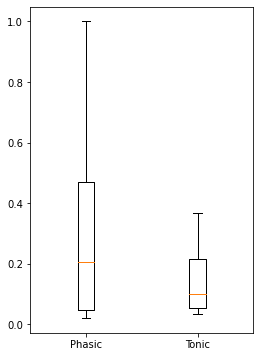

In [10]:
plt.figure(figsize=(4,6))
plt.boxplot([phasic_spectrum_mean[4:12]/phasic_spectrum_mean[4:12].max(),
             tonic_spectrum_mean[4:12]/phasic_spectrum_mean[4:12].max()],
            labels=["Phasic", "Tonic"])

In [11]:
def get_duration(episode):
    return episode[1] - episode[0]

phasic_HC = []
phasic_OC = []
tonic_HC = []
tonic_OC = []

for sample in remFolder:
    lfpREMs = sample["data"]
    metadata = sample["metadata"]
    
    #if (metadata["treatment"] == "TreatmentPositive"): # Skip CBD treatment records
    #    continue

    if metadata["condition"] == "HC":
        homecage = True
    else:
        homecage = False
    
    for lfpREM in lfpREMs:
        if(len(lfpREM) < 2500):
            break #Skip when the duration is less than a second
         
        theta = NeuralSignal(lfpREM, fs)
        theta.filter('lowpass', f_range=f_lowpass, n_seconds=lowpass_length)
        theta.segment(f_range=f_theta, threshold_episode=threshold_episode, threshold_bycycle=threshold_bycycle)

        for phasic in theta.phasic:
            if homecage:
                phasic_HC.append(get_duration(phasic))
            else:
                phasic_OC.append(get_duration(phasic))

        for tonic in theta.tonic:
            if homecage:
                tonic_HC.append(get_duration(tonic))
            else:
                tonic_OC.append(get_duration(tonic))

In [12]:
phasic = pd.concat([
    pd.DataFrame(data={"Duration (s)" : np.array(phasic_HC)/2500, "Homecage" : np.ones(len(phasic_HC), dtype=np.int8)}),
    pd.DataFrame(data={"Duration (s)" : np.array(phasic_OC)/2500, "Homecage" : np.zeros(len(phasic_OC), dtype=np.int8)})],
    axis=0)

tonic = pd.concat([
    pd.DataFrame(data={"Duration (s)" : np.array(tonic_HC)/2500, "Homecage" : np.ones(len(tonic_HC), dtype=np.int8)}),
    pd.DataFrame(data={"Duration (s)" : np.array(tonic_OC)/2500, "Homecage" : np.zeros(len(tonic_OC), dtype=np.int8)})],
    axis=0)

Text(0, 0.5, 'Duration (s)')

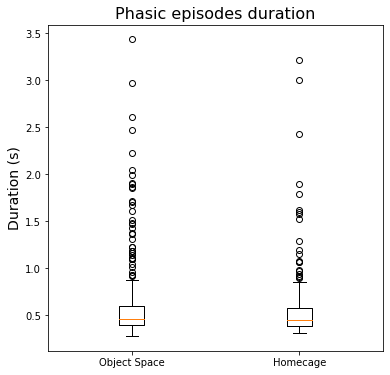

In [13]:
plt.figure(figsize=(6,6))
plt.boxplot([phasic[phasic["Homecage"] == 0]["Duration (s)"],
             phasic[phasic["Homecage"] == 1]["Duration (s)"]],
             labels=["Object Space", "Homecage"])
plt.title("Phasic episodes duration", fontsize=16)
plt.ylabel("Duration (s)", fontsize=14)

Text(0, 0.5, 'Duration (s)')

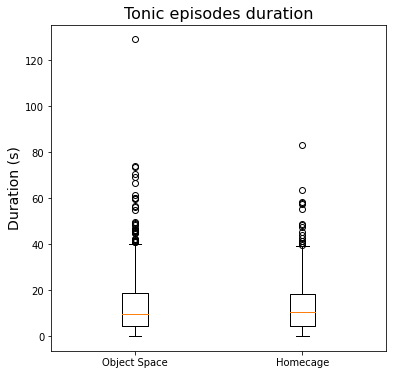

In [14]:
plt.figure(figsize=(6,6))
plt.boxplot([tonic[tonic["Homecage"] == 0]["Duration (s)"],
             tonic[tonic["Homecage"] == 1]["Duration (s)"]],
             labels=["Object Space", "Homecage"])
plt.title("Tonic episodes duration", fontsize=16)
plt.ylabel("Duration (s)", fontsize=14)